# Customer Personality Analysis
Customer Personality Analysis is one the most important applications of unsupervised learning. Using clustering techniques, companies can identify the several segments of customers allowing them to target the potential user base. In this machine learning project, we will make use of K-means clustering which is the essential algorithm for clustering unlabeled dataset. Before ahead in this project, learn what actually Customer Personality Analysis is.


# Data Preprocessing

#### Import the Required Libraries from Python.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.cluster import KMeans,AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,silhouette_score,davies_bouldin_score,calinski_harabasz_score


import warnings
warnings.filterwarnings('ignore')

#### Loading and Reading the Dataset.

In [33]:
data=pd.read_excel("marketing_campaign.xlsx")

In [34]:
# Displaying Fisrt 10 Records.
data.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,2013-09-09,16,520,...,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,2012-11-13,34,235,...,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,2013-05-08,32,76,...,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,2013-06-06,19,14,...,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,2014-03-13,68,28,...,20,1,0,0,0,0,0,3,11,0


In [35]:
# Displaying Data_Types of data Columns.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [36]:
# Checking for Null or Missing Values in the data.
data.isnull().sum()   # Only Income has the Null values.

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

#### Summary Statistics.

In [38]:
data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274


In [39]:
data[data.duplicated()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response


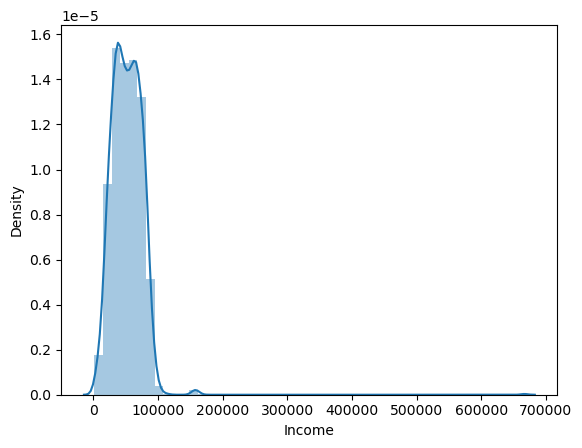

In [40]:
sns.distplot(data['Income'])
plt.show()

## Exploratory Data Analysis.

#### Handling Null or Missing Values.

In [43]:
data['Income'].fillna(data['Income'].median(),inplace=True)

In [44]:
# Checking whether Missing or Null Values are Handled or not.
data.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

## Visualizations.

#### Histograms.

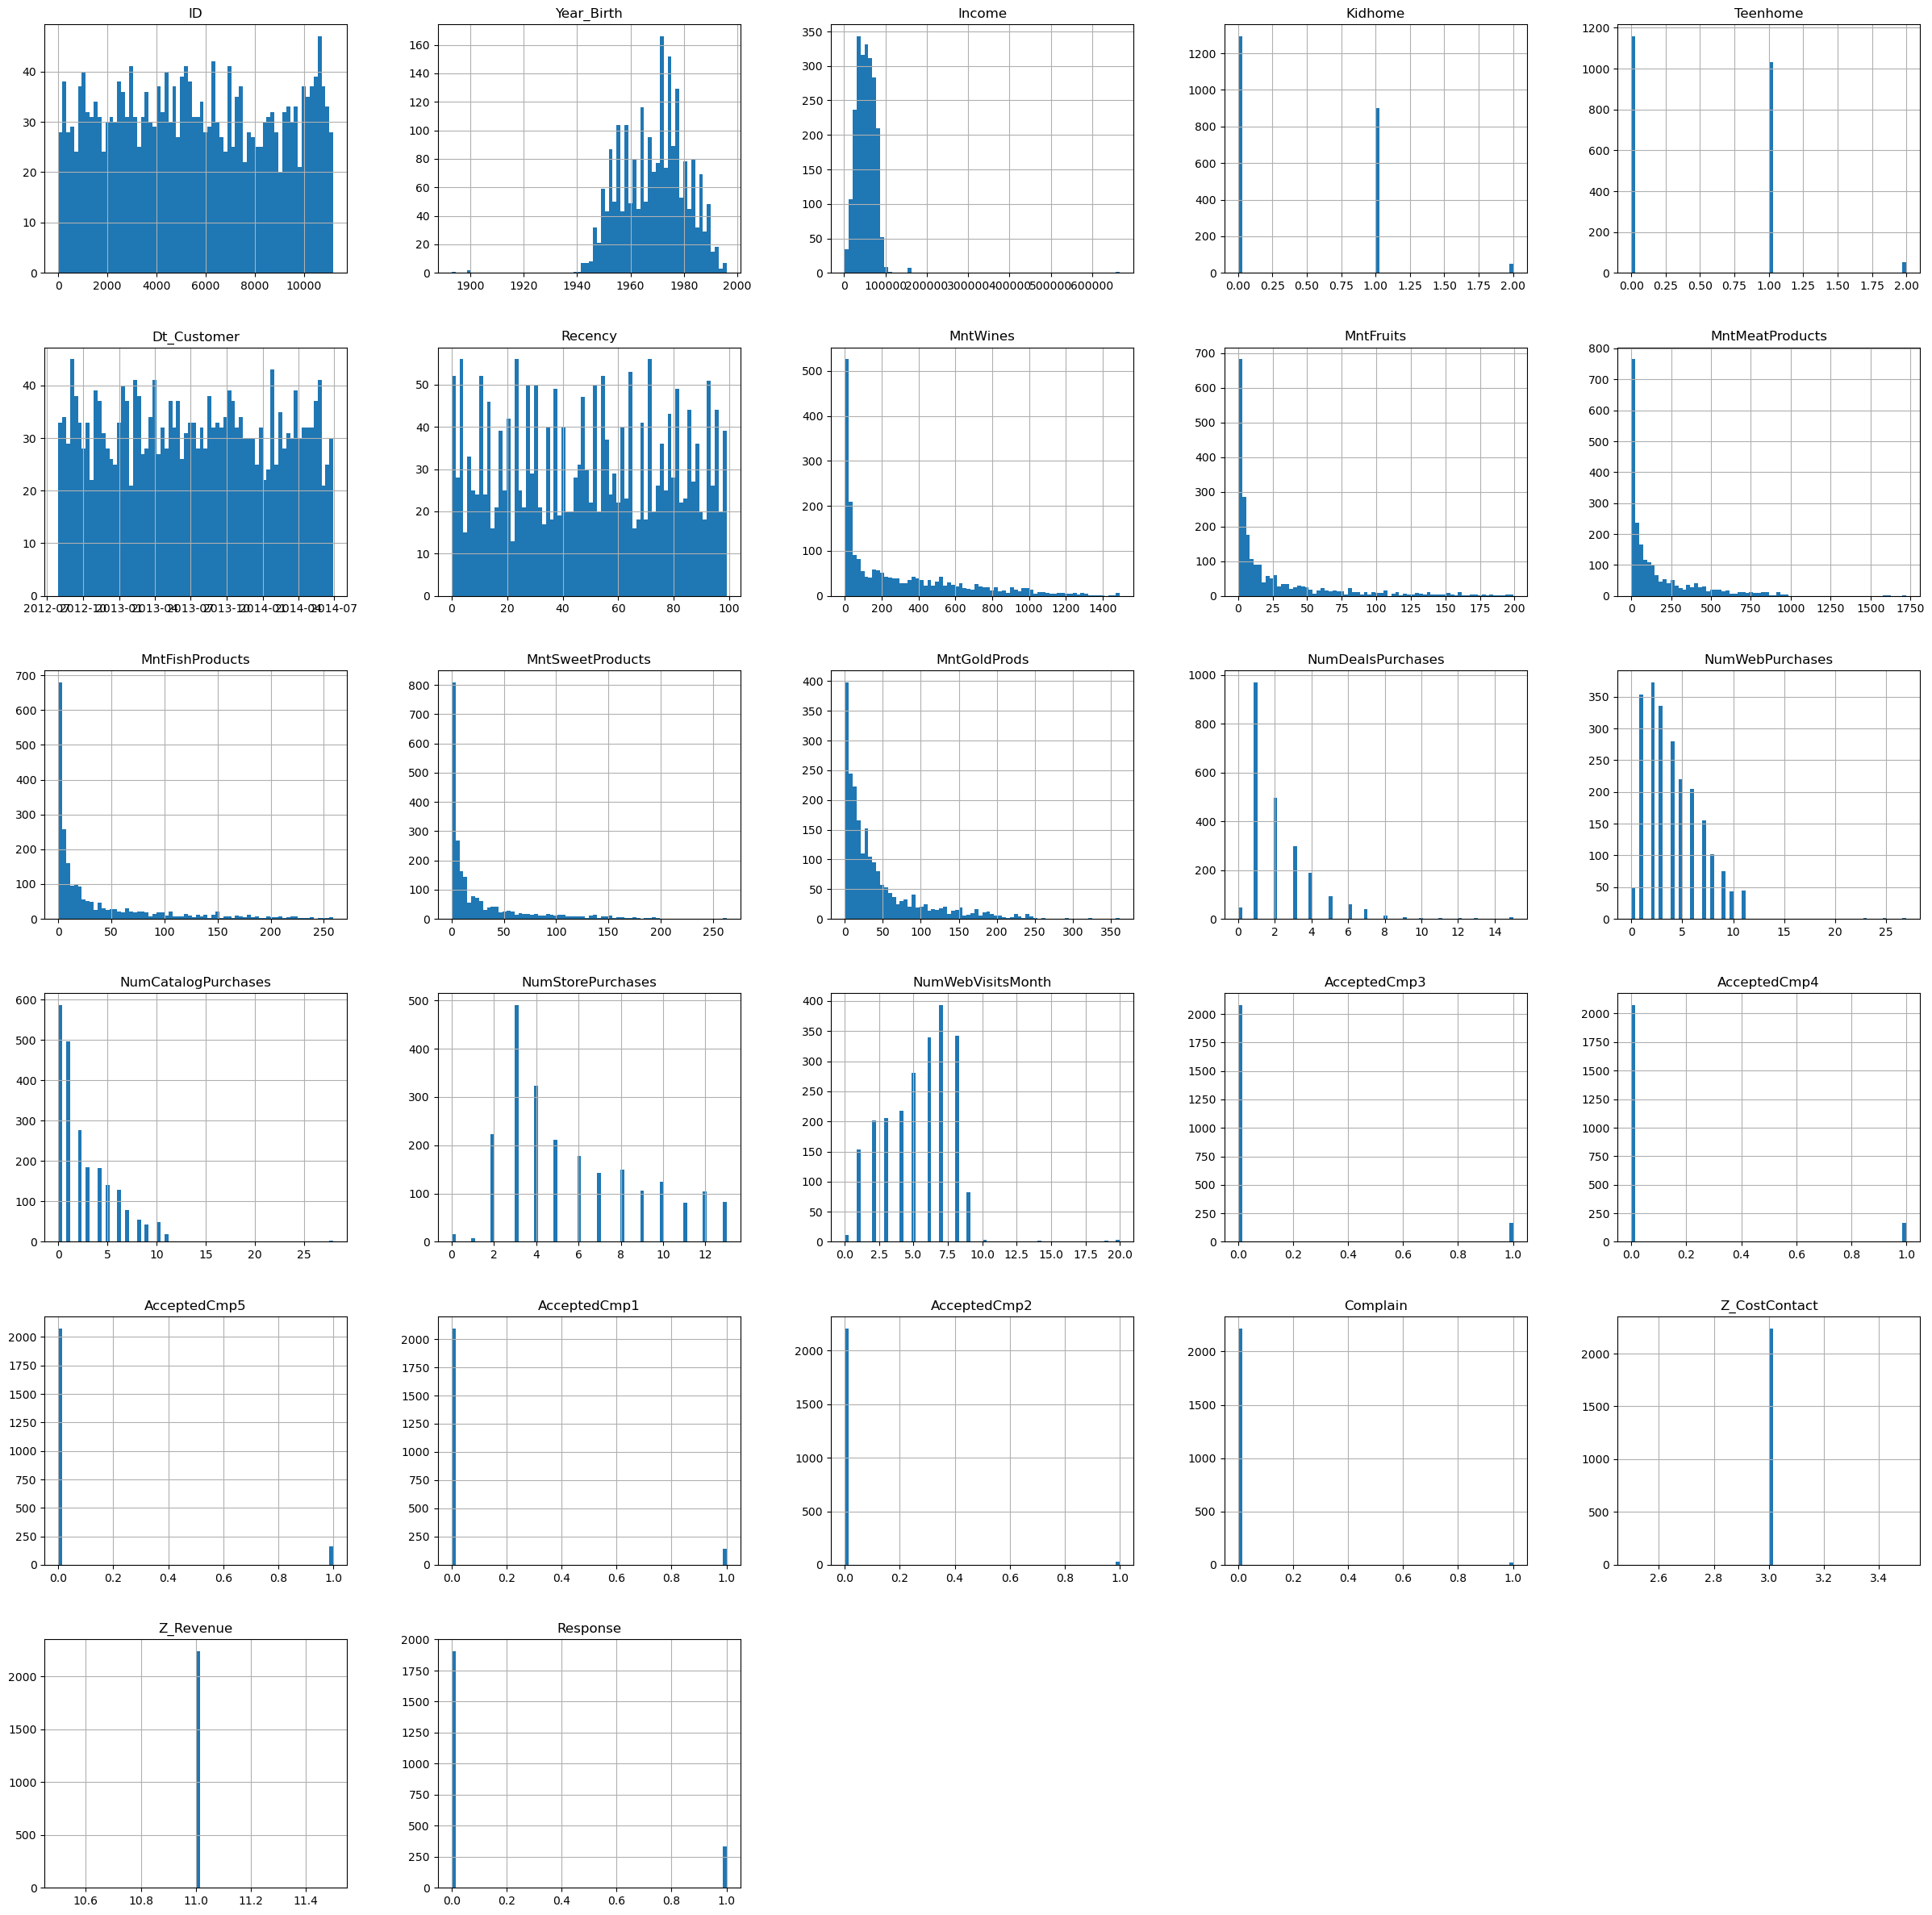

In [47]:
data.hist(bins=70,figsize=(30,30))
plt.show()

#### Boxplots

In [49]:
num_cols=data.select_dtypes(include=['int64','float64']).columns

In [50]:
num_cols

Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact',
       'Z_Revenue', 'Response'],
      dtype='object')

#### Outlier Detections.

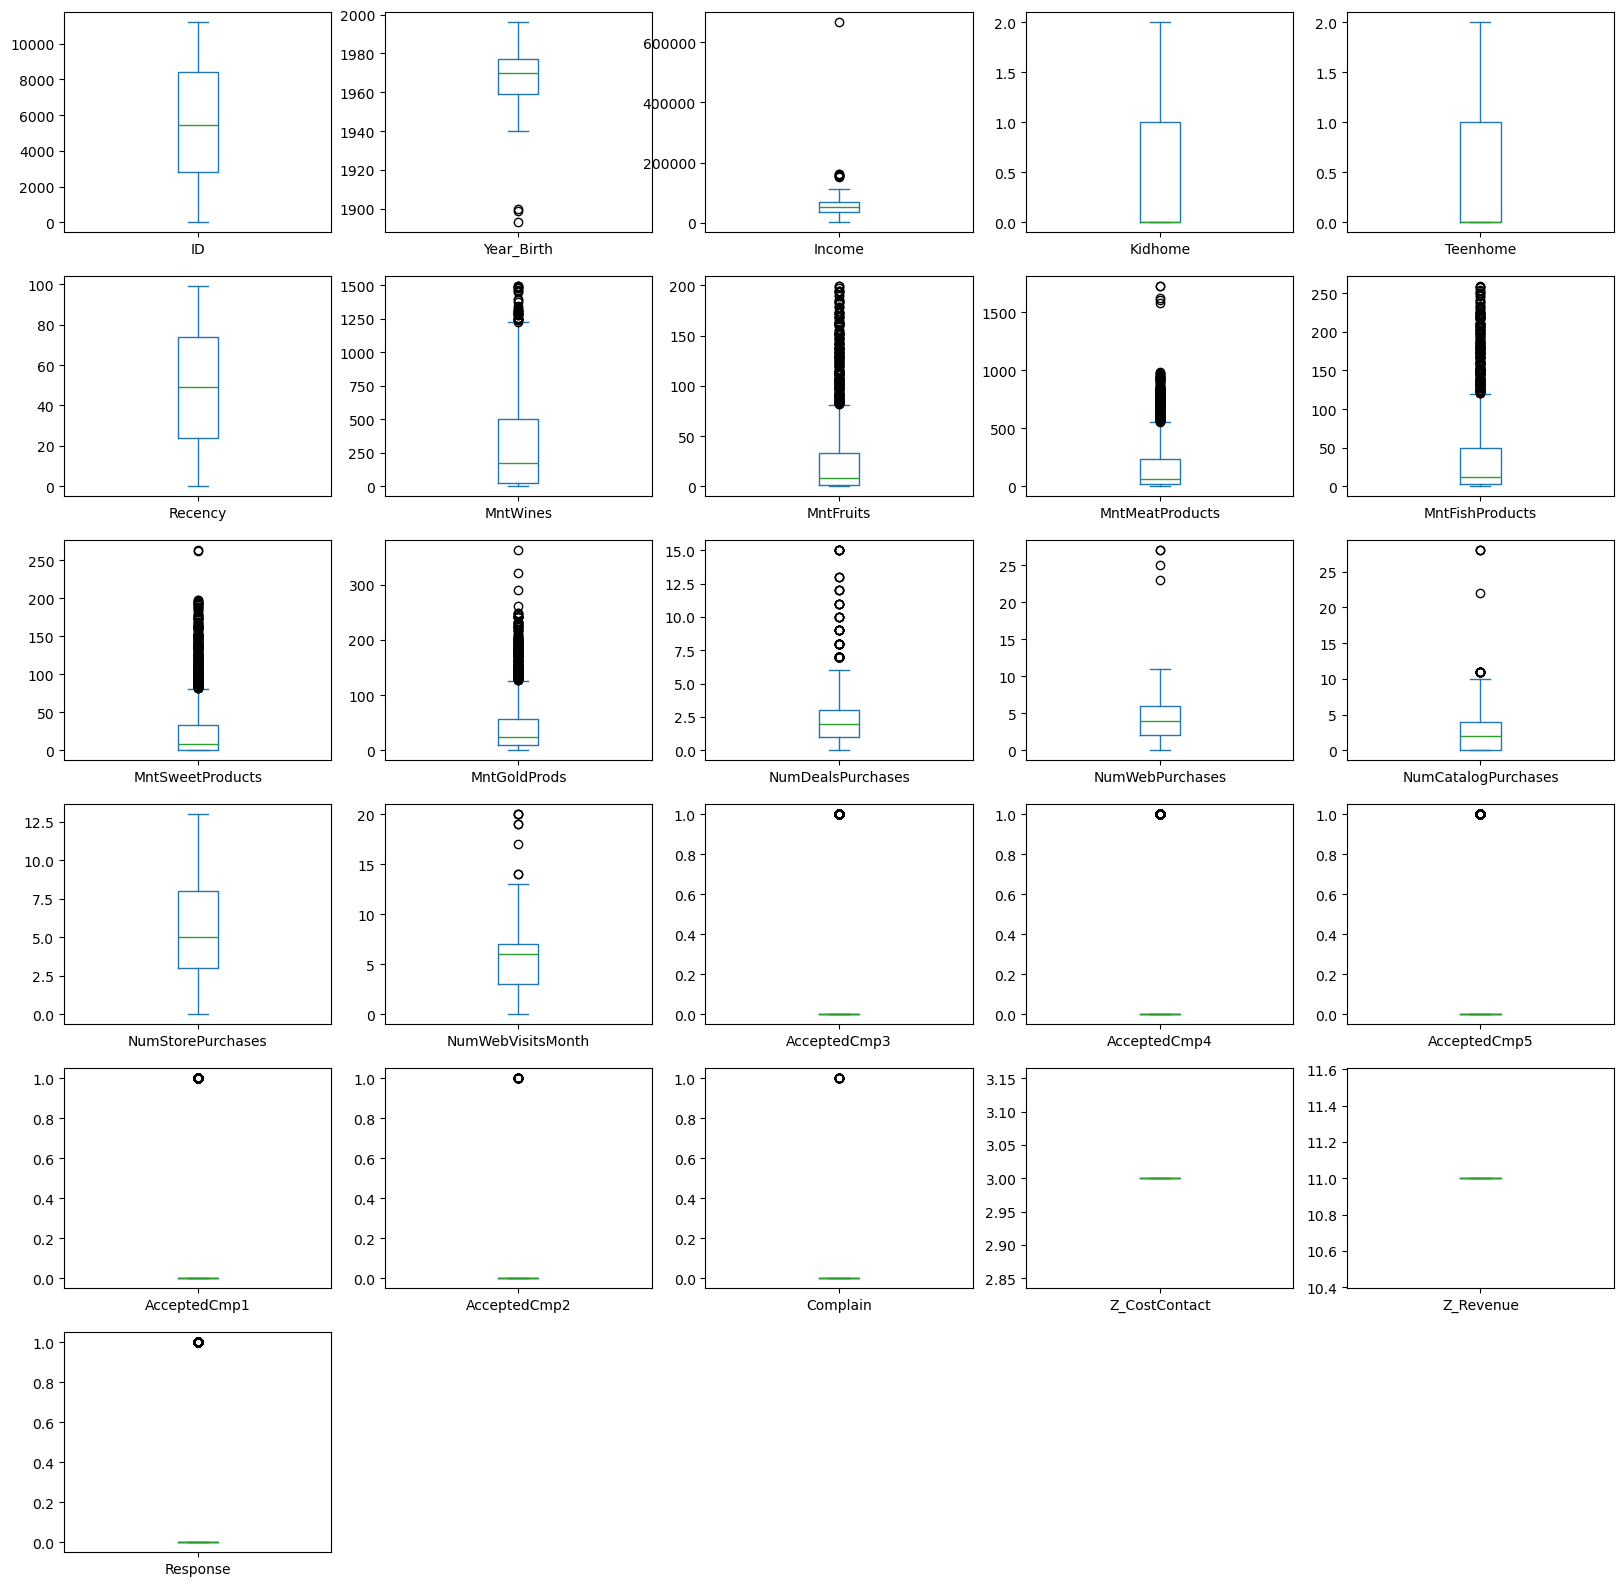

In [52]:
data[num_cols].plot(kind='box',subplots=True,layout=(6,5),figsize=(20,20))
plt.show()

In [53]:
# Detecting and removing outliers using the IQR method.
def handle_outlier(data,columns):
    outliers_info={}
    for col in columns:
        Q1=data[col].quantile(0.25)     # First quartile (25th percentile)
        Q3=data[col].quantile(0.75)     # Third quartile (75th percentile)
        IQR=Q3-Q1                       # Interquartile range
        lower_bound=Q1-1.5*IQR          # Lower bound for outliers
        upper_bound=Q3+1.5*IQR          # Upper bound for outliers

        # Identify outliers
        outliers=data[(data[col]<lower_bound) | (data[col]>upper_bound)]
        outliers_info[col]=len(outliers)  # Count of outliers
        # Remove outliers from the dataset
        data=data[(data[col]>=lower_bound)&(data[col]<=upper_bound)]
    return data,outliers_info

In [54]:
pure_data,outliers_summary=handle_outlier(data,num_cols)

In [55]:
outliers_summary

{'ID': 0,
 'Year_Birth': 3,
 'Income': 8,
 'Kidhome': 0,
 'Teenhome': 0,
 'Recency': 0,
 'MntWines': 35,
 'MntFruits': 243,
 'MntMeatProducts': 225,
 'MntFishProducts': 218,
 'MntSweetProducts': 116,
 'MntGoldProds': 134,
 'NumDealsPurchases': 42,
 'NumWebPurchases': 38,
 'NumCatalogPurchases': 86,
 'NumStorePurchases': 110,
 'NumWebVisitsMonth': 0,
 'AcceptedCmp3': 62,
 'AcceptedCmp4': 11,
 'AcceptedCmp5': 1,
 'AcceptedCmp1': 0,
 'AcceptedCmp2': 0,
 'Complain': 10,
 'Z_CostContact': 0,
 'Z_Revenue': 0,
 'Response': 59}

#### Distribution of Various Features

In [57]:
data['Education']=data['Education'].replace(['Basic'],'Undergraduate')
data['Education']=data['Education'].replace(['PhD','2n Cycle','Master'],'Postgraduate')
data['Education']=data['Education'].replace(['Graduation'],'Graduate')

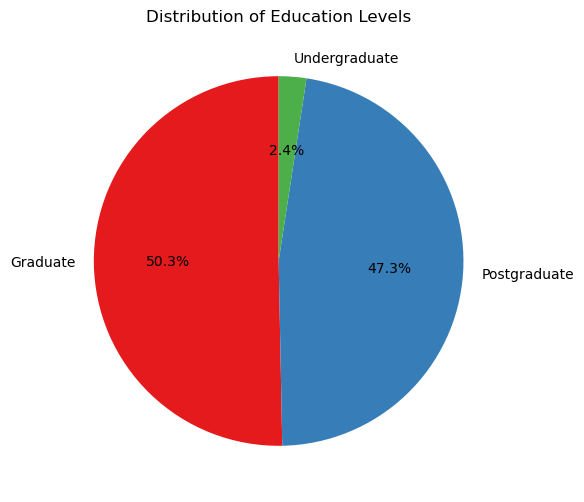

In [58]:
plt.figure(figsize=(6,6))
edu=data['Education'].value_counts()
edu.plot.pie(autopct='%1.1f%%',startangle=90,ylabel='',colors=sns.color_palette('Set1'))
plt.title('Distribution of Education Levels')
plt.show()

In [59]:
data['Marital_Status']=data['Marital_Status'].replace(['Alone','YOLO','Absurd'],'Single')

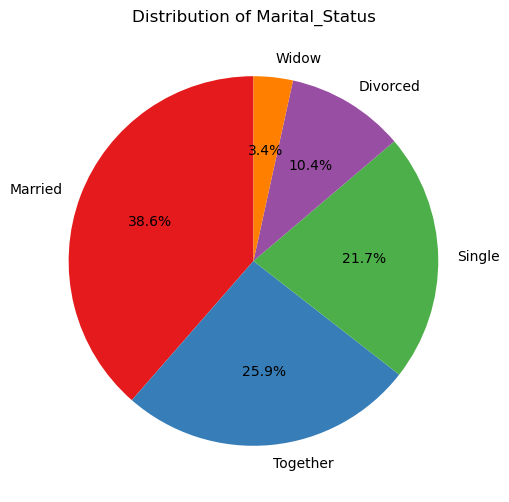

In [60]:
plt.figure(figsize=(6,6))
maris=data['Marital_Status'].value_counts()
maris.plot.pie(autopct='%1.1f%%',startangle=90,ylabel='',colors=sns.color_palette('Set1'))
plt.title('Distribution of Marital_Status')
plt.show()

<Axes: title={'center': 'Distribution of Marital_Status'}, xlabel='Marital_Status', ylabel='count'>

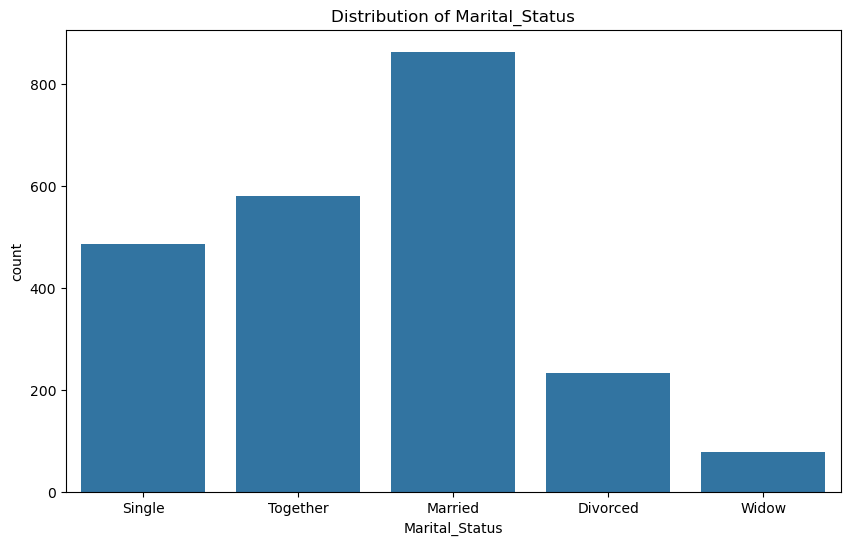

In [61]:
plt.figure(figsize=(10,6))
plt.title('Distribution of Marital_Status')
sns.countplot(data=data,x='Marital_Status')

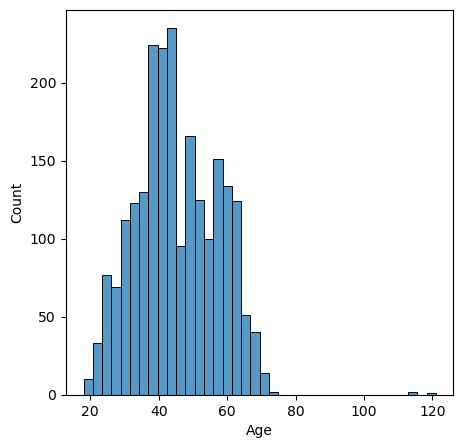

In [62]:
data['Age']=2014-data['Year_Birth']
plt.figure(figsize=(5,5))
sns.histplot(data['Age'])
plt.show()

In [63]:
# Removing outliers from age - clipping the age at 81.
data['Age']=data['Age'].clip(upper=81)

### Feature Engineering.

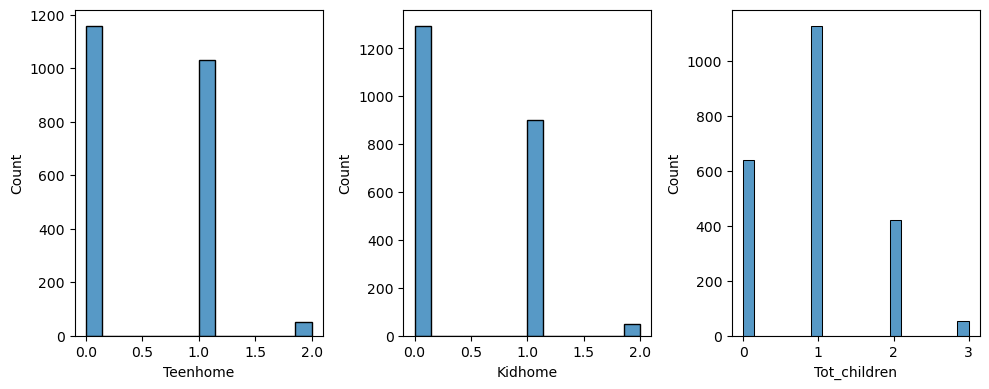

In [65]:
# Create a new variable to calculate total no. of children.
data['Tot_children']=data['Teenhome']+data['Kidhome']

fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(10,4))

sns.histplot(data['Teenhome'],ax=axes[0])
sns.histplot(data['Kidhome'],ax=axes[1])
sns.histplot(data['Tot_children'],ax=axes[2])
plt.tight_layout()
plt.show()

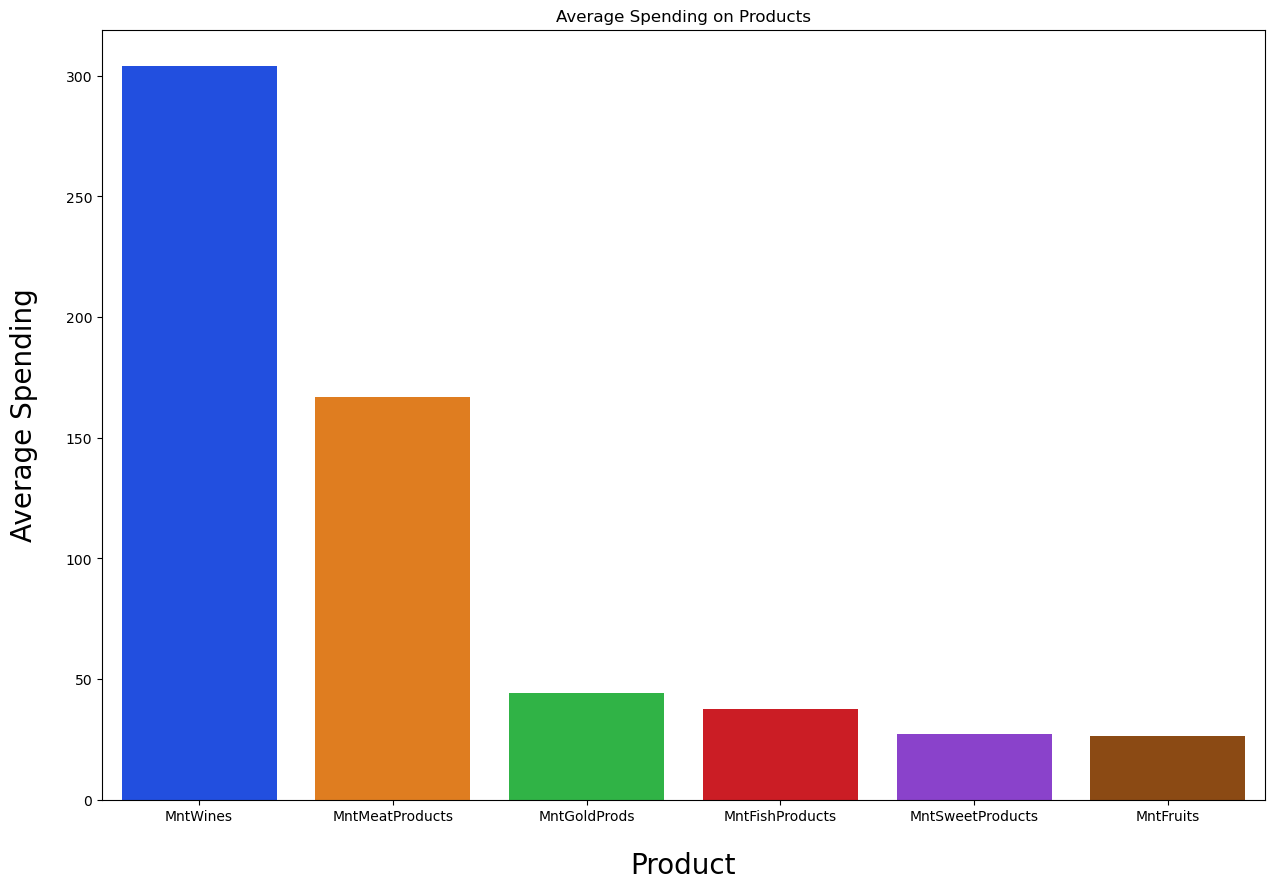

In [66]:
products=data[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']]
product_means= products.mean(axis=0).sort_values(ascending=False)
product_means_df=pd.DataFrame(list(product_means.items()),columns=['Product','Average Spending'])

plt.figure(figsize=(15,10))
plt.title('Average Spending on Products')
sns.barplot(data=product_means_df,x='Product',y='Average Spending',palette=sns.color_palette("bright"));
plt.xlabel('Product',fontsize=20,labelpad=20)
plt.ylabel('Average Spending',fontsize=20,labelpad=20);

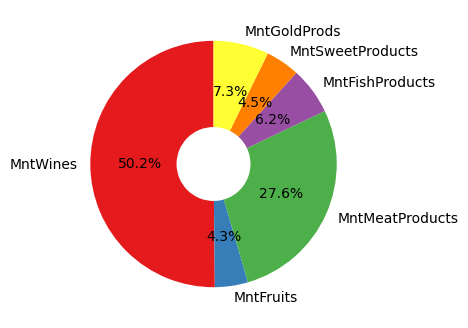

In [67]:
# Distribution of Products.
products=data.loc[:,['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']]
products_tot = products.sum()

# Products_tot
plt.figure(figsize=(4,4))
plt.pie(products_tot,labels=products_tot.index,wedgeprops={'width':0.7},textprops={'fontsize':10},autopct='%1.1f%%',startangle=90,colors=sns.color_palette('Set1'))
plt.show()

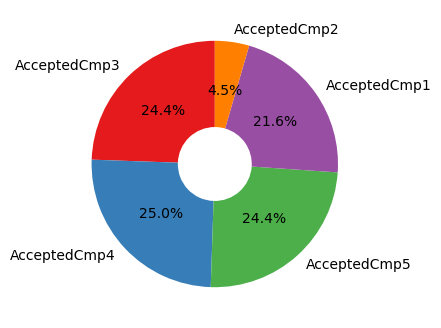

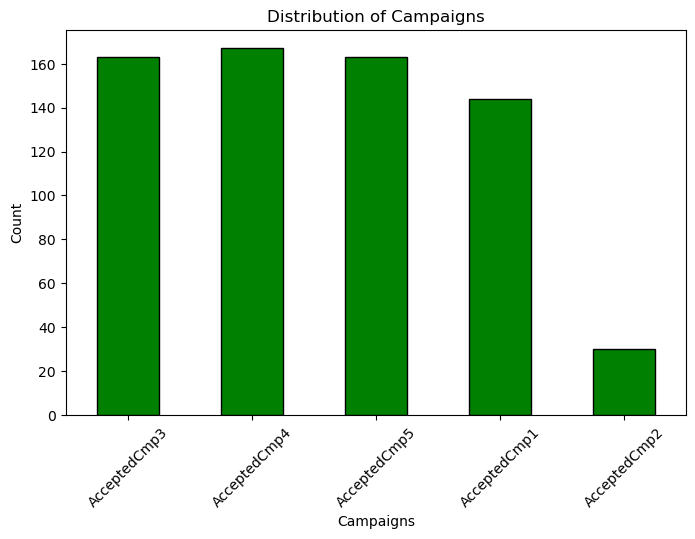

In [68]:
# Distribution of Promotion Acceptance.
promotion=data.loc[:,['AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','AcceptedCmp1','AcceptedCmp2']]
promotion_tot=promotion.sum()

# Products_tot
plt.figure(figsize=(4,4))
plt.pie(promotion_tot,labels=promotion_tot.index,wedgeprops={'width':0.7},textprops={'fontsize':10},autopct='%1.1f%%',startangle=90,colors=sns.color_palette('Set1'))
plt.show()

plt.figure(figsize=(8, 5))
promotion_tot.plot.bar(color='green',edgecolor='black')
plt.title('Distribution of Campaigns')
plt.xlabel('Campaigns')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

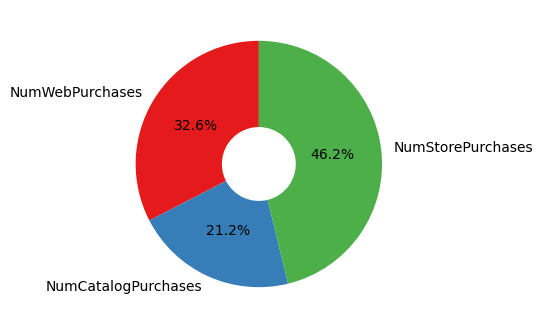

In [69]:
# Distribution of Places.
places=data.loc[:,[ 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases']]
places_tot=places.sum()

plt.figure(figsize=(4,4))
plt.pie(places_tot,labels=places_tot.index,wedgeprops={'width':0.7},textprops={'fontsize':10},autopct='%1.1f%%',startangle=90,colors=sns.color_palette('Set1'))
plt.show()

In [70]:
# Define new age bins and labels.
age_bins=[20,30,40,50,60,70,80,90]
age_labels=['20-30','30-40','40-50','50-60','60-70','70-80','80+']

# Create the 'Age_group' column with the new bins and labels.
data['Age_group']=pd.cut(data['Age'],bins=age_bins,labels=age_labels,right=False)

# Display the first few rows to confirm the new column
data[['Year_Birth','Age','Age_group']].head()

,Year_Birth,Age,Age_group
0,1957,57,50-60
1,1954,60,60-70
2,1965,49,40-50
3,1984,30,30-40
4,1981,33,30-40


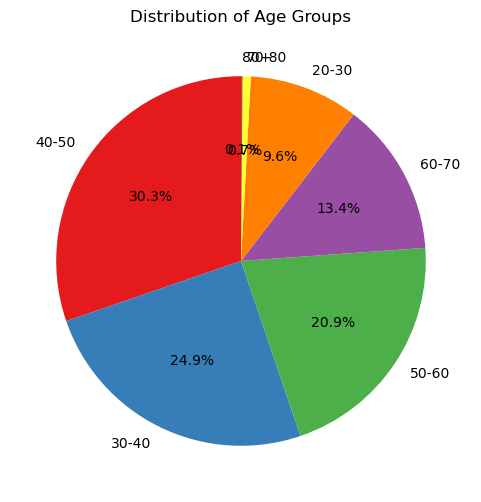

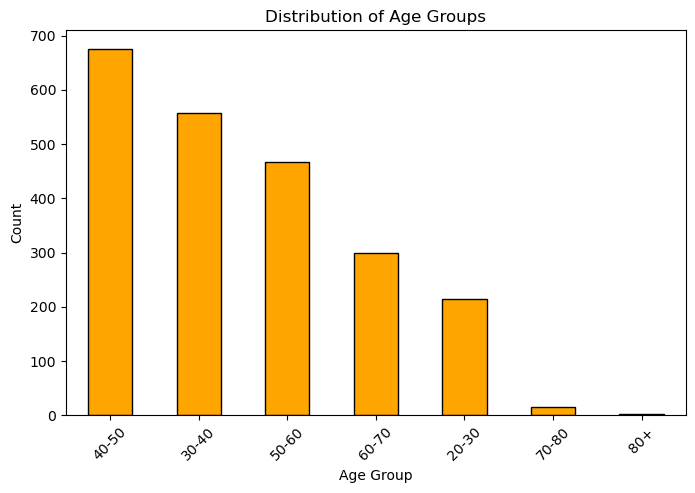

In [71]:
# Count the frequencies of each age group.
age_counts=data['Age_group'].value_counts()

# Plotting a Pie Chart for 'Age_group'
plt.figure(figsize=(6,6))
age_counts.plot.pie(autopct='%1.1f%%',startangle=90,ylabel='',colors=sns.color_palette('Set1'))
plt.title('Distribution of Age Groups')
plt.show()

# Plotting a Bar Chart for 'Age_group'
plt.figure(figsize=(8, 5))
age_counts.plot.bar(color='orange',edgecolor='black')
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Observation of Income with Age_group and Marital_status.

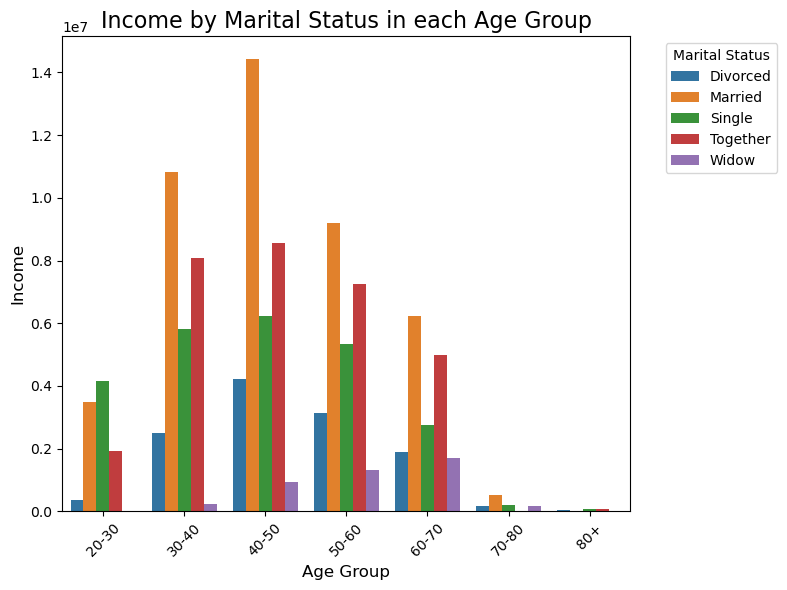

In [73]:
g1=data.groupby(['Age_group','Marital_Status'])['Income'].sum().reset_index().sort_values(by='Age_group')

fig,ax=plt.subplots(figsize=(8,6))
sns.barplot(data=g1,x='Age_group',y='Income',hue='Marital_Status')
ax.set_title('Income by Marital Status in each Age Group',fontsize=16)
ax.set_xlabel('Age Group',fontsize=12)
ax.set_ylabel('Income',fontsize=12)
ax.legend(title='Marital Status',bbox_to_anchor=(1.05,1),loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation of Income with Age_group and Education.

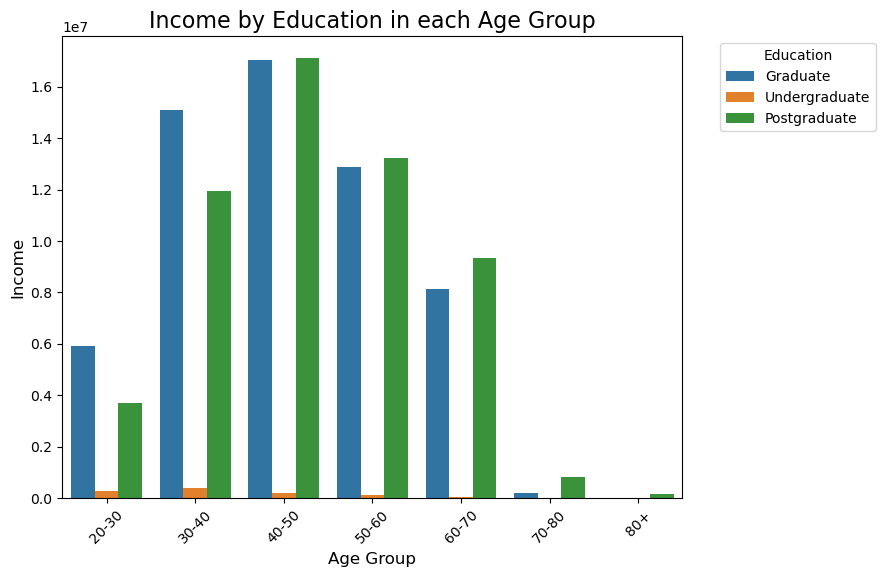

In [75]:
g2=data.groupby(['Education','Age_group'])['Income'].sum().reset_index().sort_values(by='Age_group')

fig,ax=plt.subplots(figsize=(8,6))
sns.barplot(data=g2,x='Age_group',y='Income',hue='Education')
ax.set_title('Income by Education in each Age Group',fontsize=16)
ax.set_xlabel('Age Group',fontsize=12)
ax.set_ylabel('Income',fontsize=12)
ax.legend(title='Education',bbox_to_anchor=(1.05,1),loc='upper left')
plt.xticks(rotation=45)
plt.show()

In [76]:
# Calculate the number of days each customer has been with the company.
data['Dt_Customer']=pd.to_datetime(data.Dt_Customer,format="%d-%m-%Y")
latest_date=data['Dt_Customer'].max()
data['Days_of_client']=(latest_date-data['Dt_Customer']).dt.days
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Tot_children,Age_group,Days_of_client
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,3,11,1,57,0,50-60,663
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,3,11,0,60,2,60-70,113
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,3,11,0,49,0,40-50,312
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,3,11,0,30,1,30-40,139
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,3,11,0,33,1,30-40,161


In [77]:
# Creating new columns which calculates the total expenses,accepted coupons and place of purchase.
data['Tot_Expenses']=data['MntWines']+data['MntFruits']+data['MntMeatProducts']+data['MntFishProducts']+data['MntSweetProducts']+data['MntGoldProds']
data['Tot_AcceptedCmp']=data['AcceptedCmp1']+data['AcceptedCmp2']+data['AcceptedCmp3']+data['AcceptedCmp4']+data['AcceptedCmp5']+data['Response']
data['Tot_Purchases']=data['NumWebPurchases']+data['NumCatalogPurchases']+data['NumStorePurchases']+data['NumDealsPurchases']

### Calculating the Expenses according to children in each Age Group.

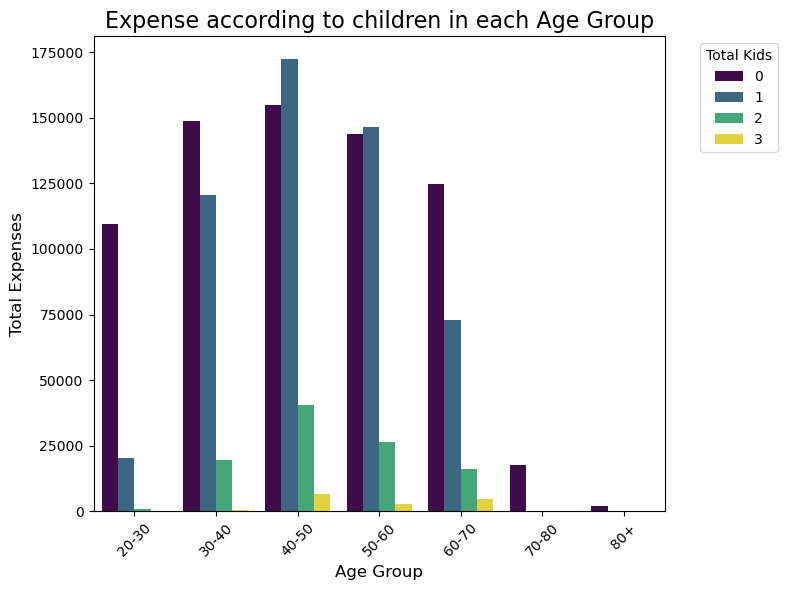

In [79]:
g3=data.groupby(['Tot_children','Age_group'])['Tot_Expenses'].sum().reset_index().sort_values(by='Age_group')

fig,ax=plt.subplots(figsize=(8,6))
sns.barplot(data=g3,x='Age_group',y='Tot_Expenses',hue='Tot_children',palette='viridis')
ax.set_title('Expense according to children in each Age Group',fontsize=16)
ax.set_xlabel('Age Group',fontsize=12)
ax.set_ylabel('Total Expenses',fontsize=12)
ax.legend(title='Total Kids',bbox_to_anchor=(1.05,1),loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

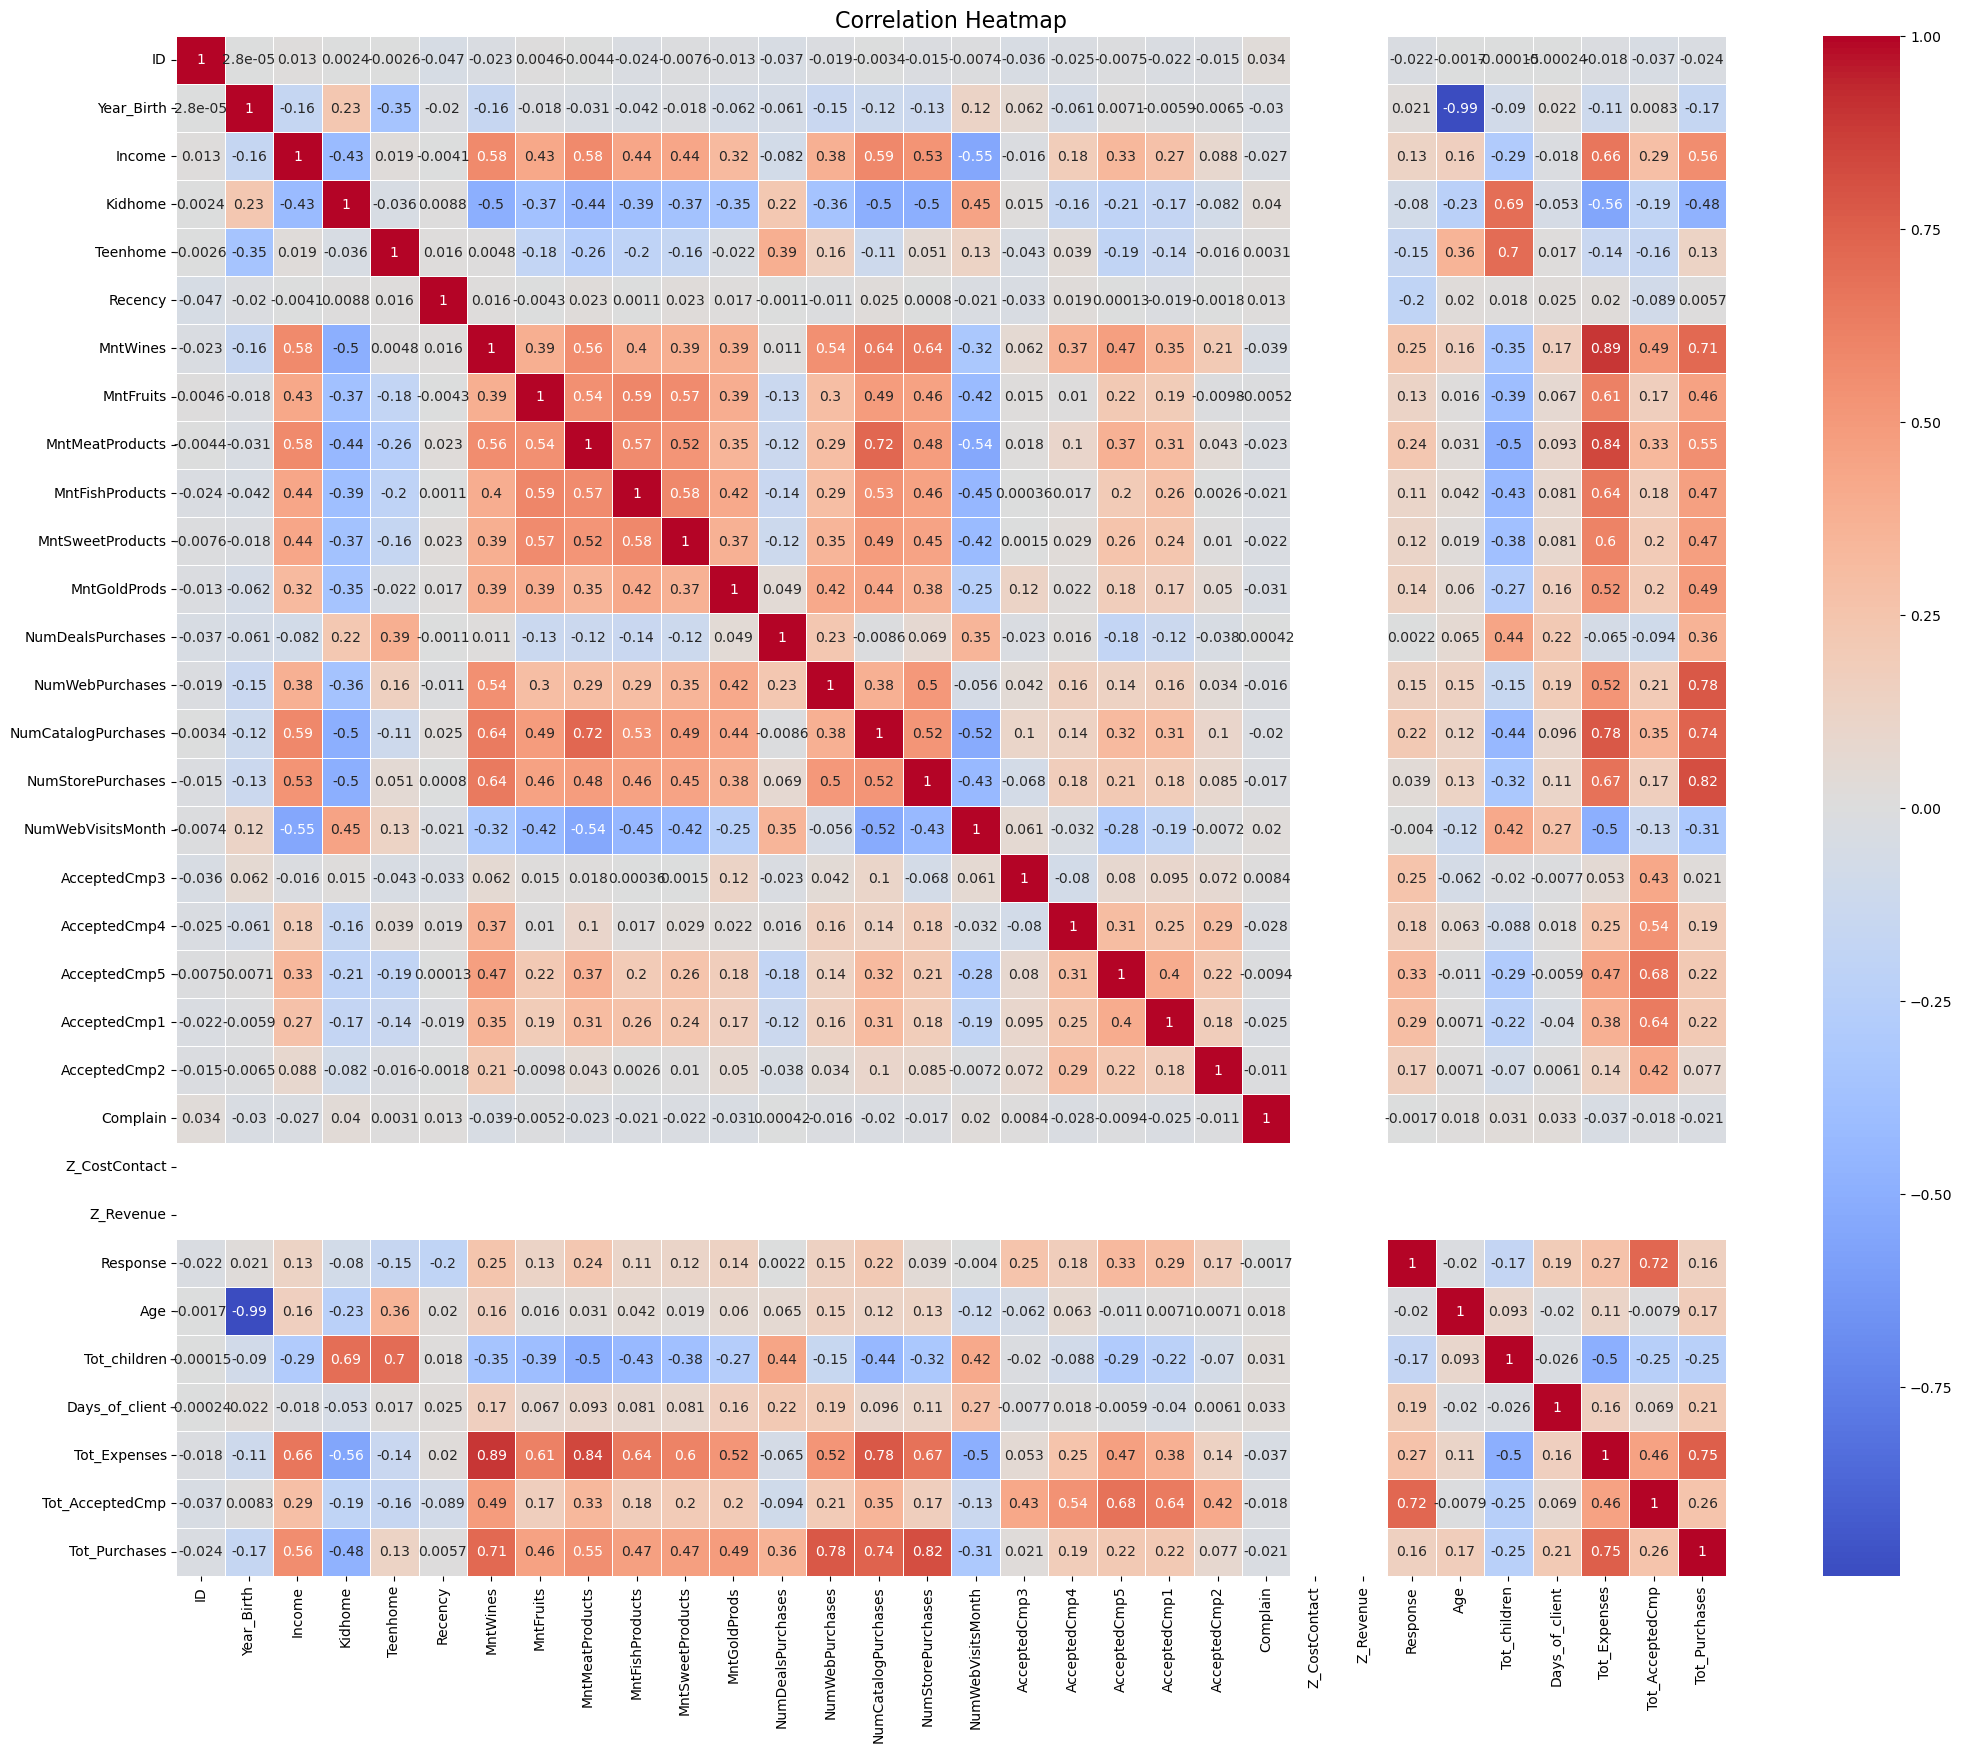

In [97]:
plt.figure(figsize=(25,20))
correlation_matrix=data.corr(numeric_only=True)
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap",fontsize=16)
plt.show()

### Observations :
1. 'Married' and 'Together' customers have the maximum income in all age groups - probably because it is the sum of two salaries.
2. Almost in all age groups customers with 0 or 1 kids spend significantly more as compared to customers with 2 or 3 kids.
3. Graduates earn the most on all age groups followed by PG.
4. Most customers are from the Age_group of 30-40 and 40-50.
5. Most of the Customers are from Graduation Education Level.
6. There are 39% of Married People in the Customers.
7. There are 30% of People are from the Age_group 50-60.
8. Most of the Income by Marital Status in each Age Group is from 40-50 and 50-60.
9. Most of the Income by Education in each Age Group is from 40-50 and 50-60.
10. Calculation of Expense according to children in each Age_group is high from the family having children with 0 and 1 child in family.






In [100]:
num_cols=data.select_dtypes(include=['float64','int64']).columns
num_cols

Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact',
       'Z_Revenue', 'Response', 'Age', 'Tot_children', 'Days_of_client',
       'Tot_Expenses', 'Tot_AcceptedCmp', 'Tot_Purchases'],
      dtype='object')

### Feature Scaling.

In [103]:
# Label encoding for the categorical columns.
le=LabelEncoder()
data['Education']=le.fit_transform(data['Education'])
data['Marital_Status']=le.fit_transform(data['Marital_Status'])

In [105]:
# Removing the unused columns from the data.
del_cols=['ID','Dt_Customer','Z_CostContact','Z_Revenue','Age_group']
data_cleaned=data.drop(columns=del_cols,axis=1)

In [107]:
#  StandardScaler for numerical columns.
scaler=StandardScaler()
data_scaled=scaler.fit_transform(data_cleaned)

In [109]:
data_scaled[:5]

array([[-9.85344730e-01, -9.54727483e-01,  2.49889629e-01,
         2.35695837e-01, -8.25217650e-01, -9.29894379e-01,
         3.07039263e-01,  9.83781265e-01,  1.55157698e+00,
         1.67970233e+00,  2.46214705e+00,  1.47650010e+00,
         8.43206907e-01,  3.49413941e-01,  1.40930394e+00,
         2.51089024e+00, -5.50784790e-01,  6.93903739e-01,
        -2.80140277e-01, -2.83830188e-01, -2.80140277e-01,
        -2.62111217e-01, -1.16510346e-01, -9.72816653e-02,
         2.38884634e+00,  1.00753185e+00, -1.26450530e+00,
         1.53118494e+00,  1.67941681e+00,  6.21248245e-01,
         1.32082612e+00],
       [-1.23573295e+00, -9.54727483e-01,  2.49889629e-01,
        -2.35454185e-01,  1.03255877e+00,  9.06934024e-01,
        -3.83664176e-01, -8.70479481e-01, -6.36301155e-01,
        -7.13225407e-01, -6.50449253e-01, -6.31503178e-01,
        -7.29005787e-01, -1.68236342e-01, -1.11040937e+00,
        -5.68719619e-01, -1.16612540e+00, -1.30463472e-01,
        -2.80140277e-01, -2.83

# Data Splitting.

In [112]:
X=data_cleaned
y=data['Response']

In [114]:
# Train-Test Split.
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

## Model Building.

### K-Means
K-means clustering is a popular method for grouping data by assigning observations to clusters based on proximity to the cluster’s center. This article explores k-means clustering, its importance, applications, and workings, providing a clear understanding of its role in data analysis.

In [118]:
# Using the Elbow method to find the optimal number of clusters.
inertia=[]
cluster_range=range(1,11)  # Test of 1 to 10 clusters.

for k in cluster_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

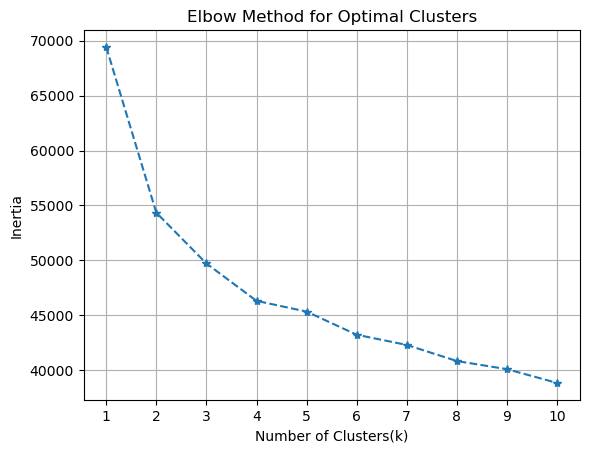

In [119]:
# Plotting the Elbow curve.
plt.plot(cluster_range,inertia,marker='*',linestyle='--')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters(k)')
plt.ylabel('Inertia')
plt.xticks(cluster_range)
plt.grid()
plt.show()

In [121]:
# Choose the optimal number of clusters.
opt_k=4
kmeans=KMeans(n_clusters=opt_k,random_state=42)
labels=kmeans.fit_predict(data_scaled)

#### Elbow Method :
The elbow method is a graphical method for finding the optimal K value in a k-means clustering algorithm.

#### Silhouette Score :
Measures how well samples are clustered. Higher values (close to 1) indicate better-defined clusters.

#### Davies-Bouldin Index :
The Davies-Bouldin Index (DBI) is a metric for evaluating clustering algorithms. It is an internal evaluation scheme, where the validation of how well the clustering has been done is made using quantities and features inherent to the dataset. The lower the DBI value, the better the clustering quality, with a minimum score of 0 indicating optimal clustering.

In [127]:
# Evaluation Metrics.
silhouette=silhouette_score(data_scaled,labels)
davies_bouldin=davies_bouldin_score(data_scaled,labels)


print(f"Silhouette Score:{silhouette:.4f}")
print(f"Davies-Bouldin Index:{davies_bouldin:.4f}")

Silhouette Score:0.1725
Davies-Bouldin Index:2.1188


### Random Forest Model.

In [130]:
# Train Random Forest Model.
model=RandomForestClassifier(random_state=42)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)
# Evaluate Model.
accuracy=accuracy_score(y_test,y_pred)
report=classification_report(y_test,y_pred)
conf_matrix=confusion_matrix(y_test,y_pred)

print(f"Random Forest Model Accuracy Score:{accuracy:.4f}")
print(f"Classification report:{report}")
print(f"Confusion Matrix :{conf_matrix}")

Random Forest Model Accuracy Score:1.0000
Classification report:              precision    recall  f1-score   support

           0       1.00      1.00      1.00       577
           1       1.00      1.00      1.00        95

    accuracy                           1.00       672
   macro avg       1.00      1.00      1.00       672
weighted avg       1.00      1.00      1.00       672

Confusion Matrix :[[577   0]
 [  0  95]]


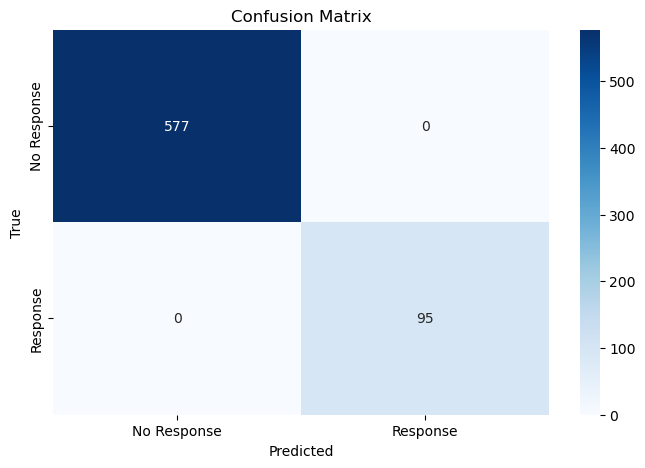

In [132]:
# Plot Confusion Matrix.
plt.figure(figsize=(8,5))
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues',xticklabels=['No Response','Response'],yticklabels=['No Response','Response'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Agglomerative Clustering

In [135]:
# Agglomerative Clustering.
agg_cluster=AgglomerativeClustering(n_clusters=4,linkage='ward')
labels_agg=agg_cluster.fit_predict(data_scaled)

silhouette_agg=silhouette_score(data_scaled,labels_agg)
print(f"Agglomerative Clustering Silhouette Score:{silhouette_agg:.4f}")

Agglomerative Clustering Silhouette Score:0.1824


### Gaussian Mixture Model (GMM)

In [138]:
# Gaussian Mixture Clustering.
gmm=GaussianMixture(n_components=4,random_state=42)
labels_gmm=gmm.fit_predict(data_scaled)

# Silhouette Score
silhouette_gmm=silhouette_score(data_scaled,labels_gmm)
print(f"Gaussian Mixture Silhouette Score:{silhouette_gmm:.4f}")

Gaussian Mixture Silhouette Score:0.2076
